In [ ]:
#1 import the libraries
#2 Load the dataset
#3 EDA
#4 Encoding Categorical Variable
#5 Feature Scaling
#6 Split the data into the training and testing
#5 Feature Scaling
7# Train the model
8# Test the model
9# Evaluate the model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the dataset
path="/content/drive/MyDrive/ML/50_Startups.csv"
dataset=pd.read_csv(path)
#Check the values
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
#get the no of row and Cols
print("No of Rows",dataset.shape[0])
print("No of Cols",dataset.shape[0])

No of Rows 50
No of Cols 50


In [ ]:
#get the information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [ ]:
#null check
dataset.isna().sum()

,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


In [ ]:
#duplicate value
dataset.duplicated().sum()

np.int64(0)

In [ ]:
dataset.describe() # Statistical information of all the numerical values

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


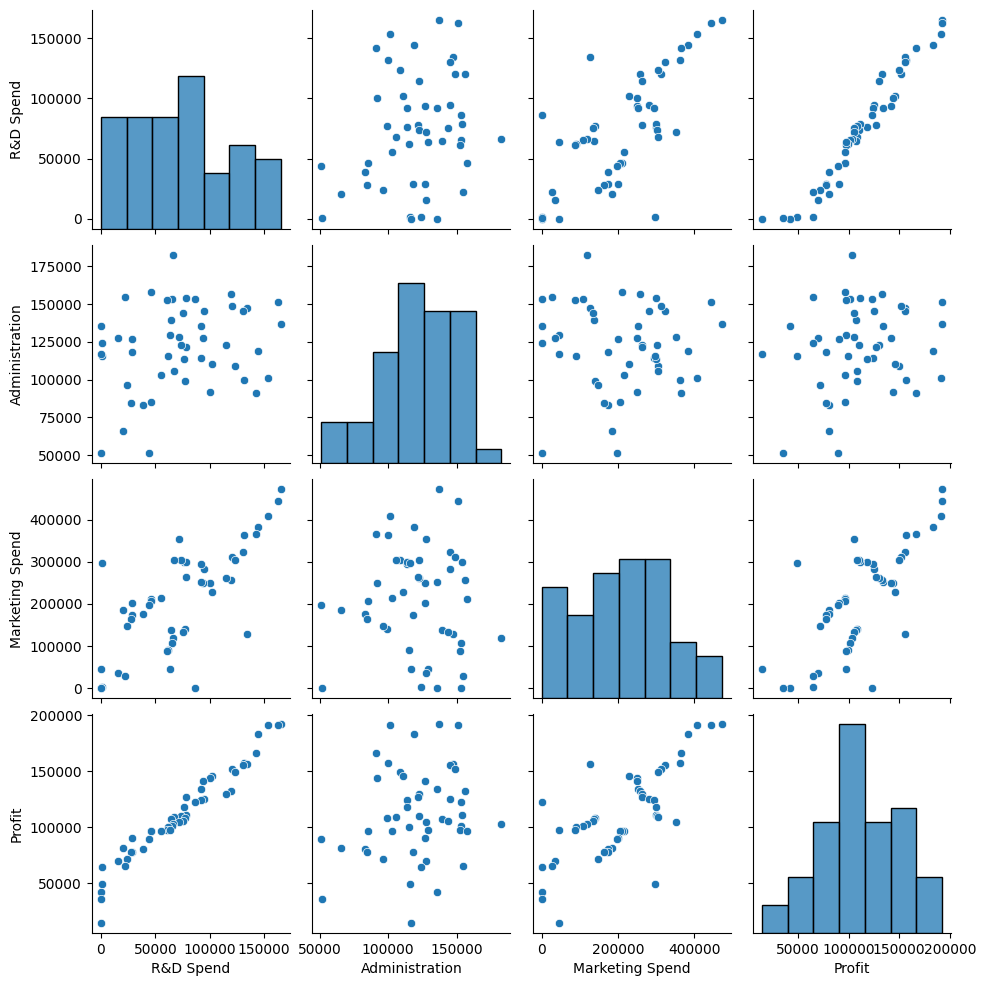

In [ ]:
#check the relationship btwn independent variable and dependant variables
sns.pairplot(dataset)

In [ ]:
#from the above pairplot we caome to can say:
1 R&D spend has positive relationship with the marketing spend & Profit
2 Marketing spend has positive relationship with the marketing spend & Profit
3 Administration has no relationship with the marketing spend & Profit
4 State has no relationship with the profit


In [ ]:
#statitical information of non numerical colums
dataset.describe(include='object')

,State
count,50
unique,3
top,New York
freq,17


In [ ]:
dataset['State'].unique() #check the unique values of the column

array(['New York', 'California', 'Florida'], dtype=object)

In [ ]:
#no of data for each unique values
dataset['State'].value_counts()

,count
State,
New York,17
California,17
Florida,16


In [ ]:
#Creat a new datframe
df_new=dataset.drop(columns='State')
df_new

,R&D Spend,Administration,Marketing Spend,Profit
0,165349.20,136897.80,471784.10,192261.83
1,162597.70,151377.59,443898.53,191792.06
2,153441.51,101145.55,407934.54,191050.39
3,144372.41,118671.85,383199.62,182901.99
4,142107.34,91391.77,366168.42,166187.94
5,131876.90,99814.71,362861.36,156991.12
6,134615.46,147198.87,127716.82,156122.51
7,130298.13,145530.06,323876.68,155752.60
8,120542.52,148718.95,311613.29,152211.77
9,123334.88,108679.17,304981.62,149759.96


In [ ]:
#relationship between the variables
from scipy.stats import pearsonr

for column in df_new.columns:
  if column != ('Profit' 'State'):
    corr, p_val = pearsonr(df_new[column], df_new['Profit'])
    print(f"{column}: Pearson Corr = {corr:.3f}, p-value = {p_val:.3f}")

R&D Spend: Pearson Corr = 0.973, p-value = 0.000
Administration: Pearson Corr = 0.201, p-value = 0.162
Marketing Spend: Pearson Corr = 0.748, p-value = 0.000
Profit: Pearson Corr = 1.000, p-value = 0.000


In [ ]:
#Relationship using Corr and heatmap
corr=df_new.corr()
corr

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

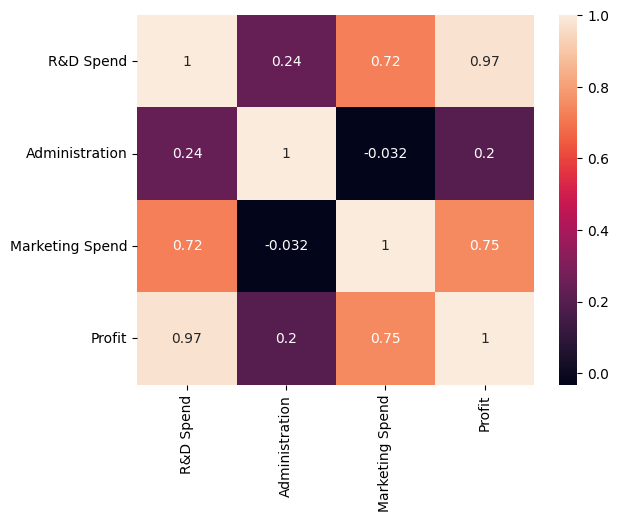

In [ ]:
#create the heatmap to find the relationship
sns.heatmap(corr,annot=True)


<Axes: >

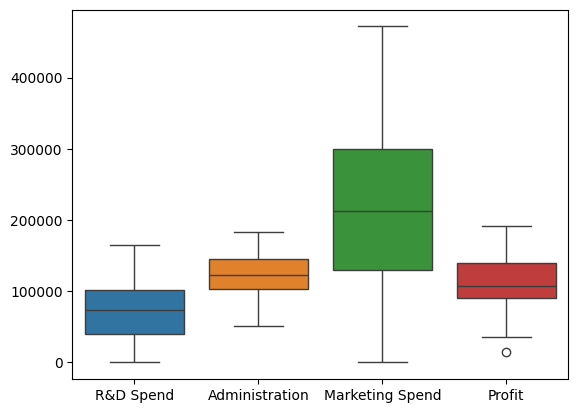

In [ ]:
sns.boxplot(dataset)

<Axes: ylabel='R&D Spend'>

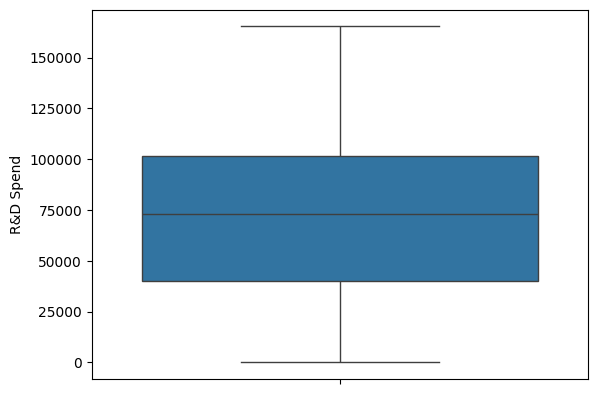

In [ ]:
sns.boxplot(dataset['R&D Spend'])

In [ ]:
#categorical Encoding
# One hot code encoding
# importing onehot encoder
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder()
X = onehotencoder.fit_transform(dataset.State.values.reshape(-1,1)).toarray()
X

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0

In [ ]:
#To add into the original dataframe
dfOneHot = pd.DataFrame(X, columns = ['Califronia','Florida','New York'])
dfOneHot

,Califronia,Florida,New York
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0
5,0.0,0.0,1.0
6,1.0,0.0,0.0
7,0.0,1.0,0.0
8,0.0,0.0,1.0
9,1.0,0.0,0.0


In [ ]:
dataset_new=pd.concat([dataset,dfOneHot],axis=1)
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [ ]:
dataset_new=pd.get_dummies(dataset)
dataset_new # onehot encoding after creating new dataset.

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,False,True
1,162597.70,151377.59,443898.53,191792.06,True,False,False
2,153441.51,101145.55,407934.54,191050.39,False,True,False
3,144372.41,118671.85,383199.62,182901.99,False,False,True
4,142107.34,91391.77,366168.42,166187.94,False,True,False
5,131876.90,99814.71,362861.36,156991.12,False,False,True
6,134615.46,147198.87,127716.82,156122.51,True,False,False
7,130298.13,145530.06,323876.68,155752.60,False,True,False
8,120542.52,148718.95,311613.29,152211.77,False,False,True
9,123334.88,108679.17,304981.62,149759.96,True,False,False


In [ ]:
# feature Scaling = All variable are in same scale so that the dataset has no any baisness, higher the values higher the weightage.
Normalisation
Standardisation
Normalization - No outliers in the dataset, values transfer to zero to one
Standardisation - Outliers in the dataset